## Objetivo:
Estudiar cómo el clustering puede ayudarnos cuando tenemos muchas observaciones, pero muy pocas etiquetas.

Trabajaremos con el conjunto de datos `digits`:
*   1,797 imagenes.
*   Dígitos del 0 al 9.
*   imagenes de 8 × 8 píxeles.
*   64 características por observación.

**Suposición:** Tienes todas las imagenes, pero solamente puedes utilizar 50 etiquetas para entrenar inicialmente el modelo.

In [ ]:
from sklearn.datasets import load_digits
X_digits, y_digits = load_digits(
return_X_y=True
)
X_train = X_digits[:1400]
y_train = y_digits[:1400]
X_test = X_digits[1400:]
y_test = y_digits[1400:]

## Visualización de los datos con Reducción de Dimensionalidad

Vamos a aplicar diferentes algoritmos de reducción de dimensionalidad para visualizar la distribución de los dígitos en 2 dimensiones. Esto nos ayudará a entender la estructura de los datos antes de proceder con el clustering y la clasificación.

### t-Distributed Stochastic Neighbor Embedding (t-SNE)

t-SNE es una técnica no lineal de reducción de dimensionalidad utilizada para visualizar conjuntos de datos de alta dimensión. Es particularmente efectiva para revelar agrupaciones en los datos.

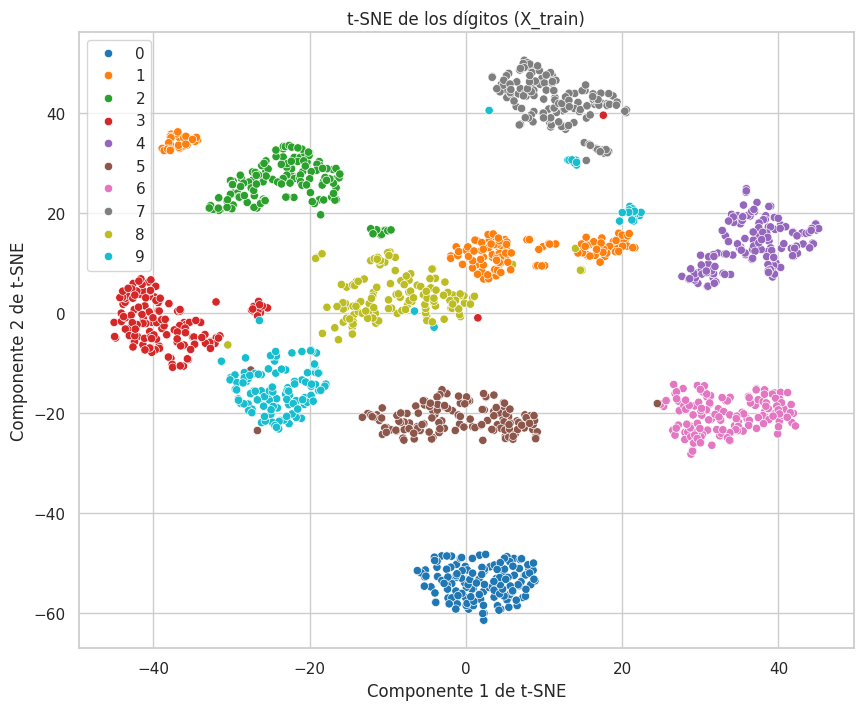

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Aplicar t-SNE
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_train_tsne = tsne.fit_transform(X_train)

# Visualizar los resultados
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_train_tsne[:, 0],
    y=X_train_tsne[:, 1],
    hue=y_train,
    palette='tab10',
    legend='full'
)
plt.title('t-SNE de los dígitos (X_train)')
plt.xlabel('Componente 1 de t-SNE')
plt.ylabel('Componente 2 de t-SNE')
plt.show()

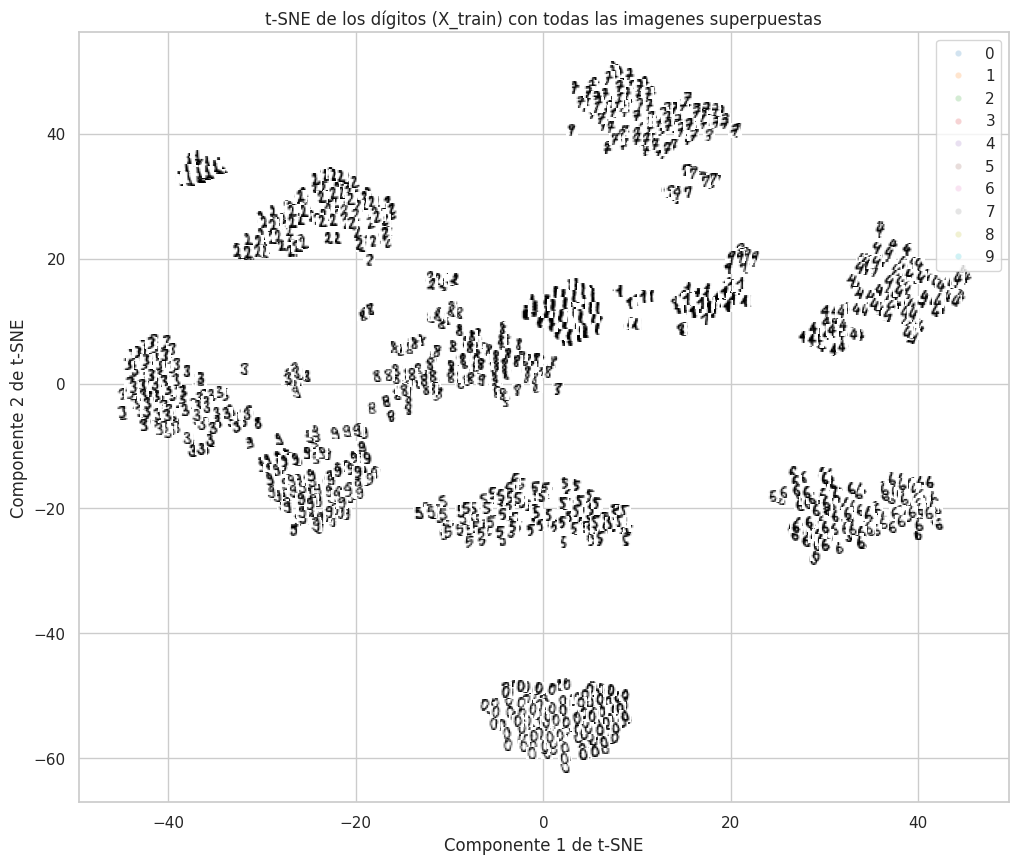

In [ ]:
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

fig, ax = plt.subplots(figsize=(12, 10))

# 1. Plot all points with lower alpha
sns.scatterplot(
    x=X_train_tsne[:, 0],
    y=X_train_tsne[:, 1],
    hue=y_train,
    palette='tab10',
    legend='full',
    alpha=0.2, # Lower alpha for background points
    s=20, # Smaller points for background scatter
    ax=ax
)

# 2. Select all images to superimpose
# num_total_images_to_show = 100 # Original line for random subset
all_indices = np.arange(len(X_train)) # Use all indices

for i in all_indices:
    x0, y0 = X_train_tsne[i] # t-SNE coordinates
    img = X_train[i].reshape(8, 8) # Original 8x8 image

    # Create an OffsetImage (zoom adjusted for 8x8 images to be visible)
    imagebox = OffsetImage(img, cmap='binary', zoom=1.0)

    # AnnotationBbox to place the image without an arrow and centered on the point
    ab = AnnotationBbox(imagebox, (x0, y0),
                        xycoords='data',
                        xybox=(0,0), # No offset from the data point
                        boxcoords='offset points', # Box coordinates are offset from the data point
                        frameon=False, # No frame around the image
                        pad=0.0
                       )
    ax.add_artist(ab)

ax.set_title('t-SNE de los dígitos (X_train) con todas las imagenes superpuestas') # Updated title
ax.set_xlabel('Componente 1 de t-SNE')
ax.set_ylabel('Componente 2 de t-SNE')
plt.show()

### Uniform Manifold Approximation and Projection (UMAP)

UMAP es otra técnica de reducción de dimensionalidad no lineal que es computacionalmente más eficiente que t-SNE y a menudo preserva mejor la estructura global de los datos.

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


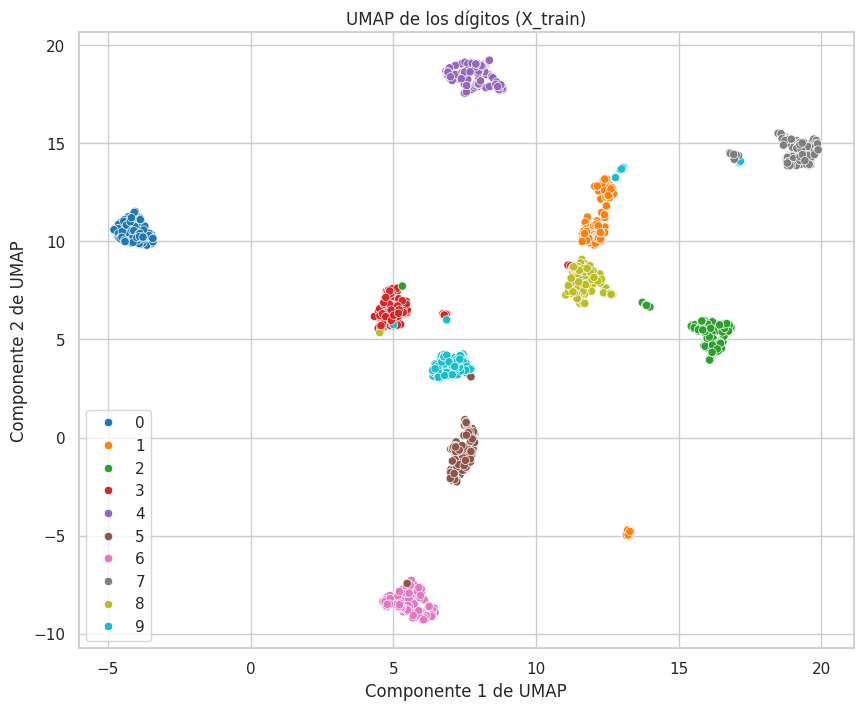

In [ ]:
# Instalar umap-learn si no está instalado
!pip install umap-learn

import umap

# Aplicar UMAP
umapper = umap.UMAP(n_components=2, random_state=42)
X_train_umap = umapper.fit_transform(X_train)

# Visualizar los resultados
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_train_umap[:, 0],
    y=X_train_umap[:, 1],
    hue=y_train,
    palette='tab10',
    legend='full'
)
plt.title('UMAP de los dígitos (X_train)')
plt.xlabel('Componente 1 de UMAP')
plt.ylabel('Componente 2 de UMAP')
plt.show()

wow! podría reconstruir un punto en (17.5, 10)? O sea, poner un punto ahí y hacer umap inverso 😭 JEAOJA y seguro es puro ruido


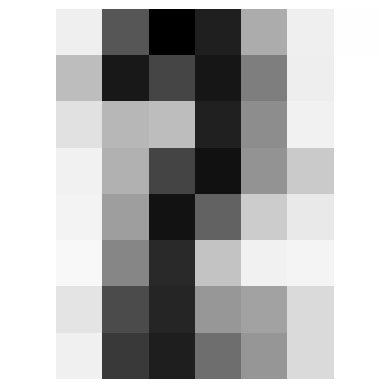

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

punto_umap = np.array([[17.5, 10]])

reconstruccion = umapper.inverse_transform(punto_umap)

imagen = reconstruccion.reshape(8, 8)

plt.imshow(imagen, cmap="binary")
plt.axis("off")
plt.show()

lol pues si JEAJAJAAJ

### Independent Component Analysis (ICA)

ICA es una técnica que busca descomponer una señal multivariante en componentes aditivas que son estadísticamente tan no gaussianas como sea posible y son mutuamente independientes.

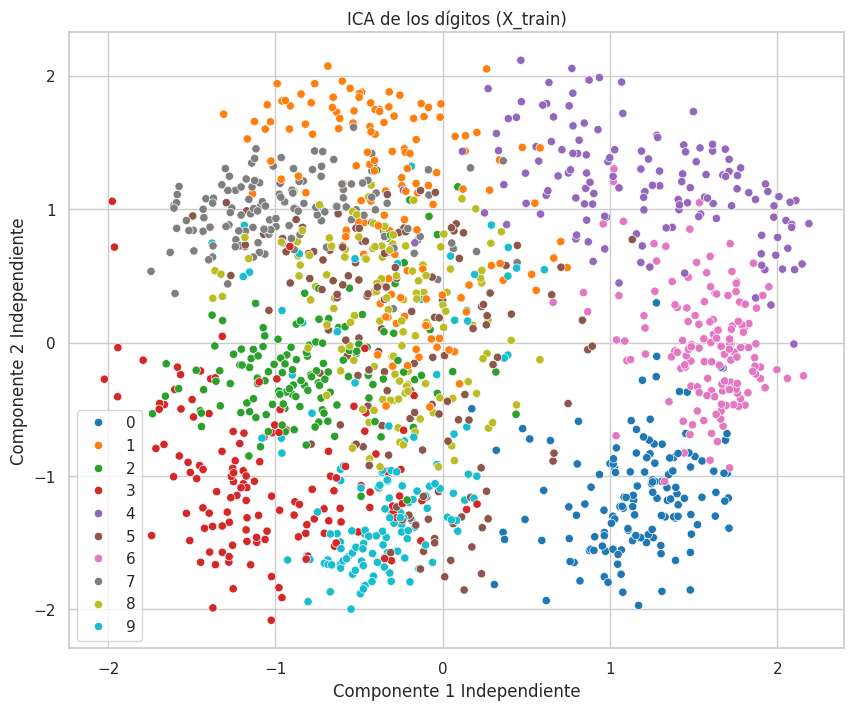

In [ ]:
from sklearn.decomposition import FastICA

# Aplicar ICA
ica = FastICA(n_components=2, random_state=42, max_iter=1000)
X_train_ica = ica.fit_transform(X_train)

# Visualizar los resultados
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_train_ica[:, 0],
    y=X_train_ica[:, 1],
    hue=y_train,
    palette='tab10',
    legend='full'
)
plt.title('ICA de los dígitos (X_train)')
plt.xlabel('Componente 1 Independiente')
plt.ylabel('Componente 2 Independiente')
plt.show()

### Principal Component Analysis (PCA)

PCA es una técnica lineal de reducción de dimensionalidad que transforma los datos a un nuevo sistema de coordenadas donde las mayores variaciones en los datos se capturan a lo largo del primer eje, la segunda mayor variación a lo largo del segundo, y así sucesivamente.

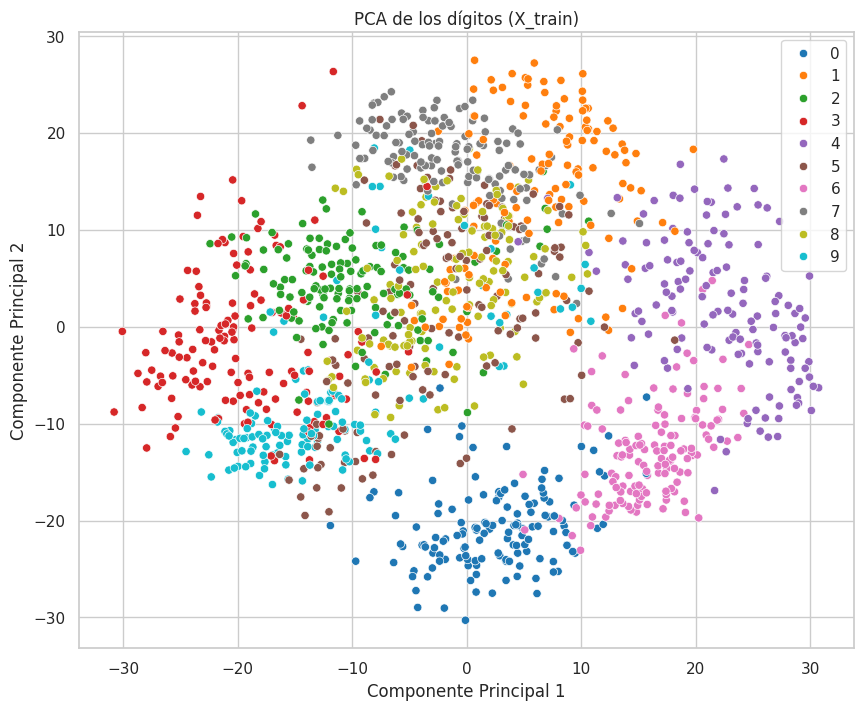

In [ ]:
from sklearn.decomposition import PCA

# Aplicar PCA
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)

# Visualizar los resultados
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train,
    palette='tab10',
    legend='full'
)
plt.title('PCA de los dígitos (X_train)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

# Datos etiquetados

Para comenzar, supón que únicamente tienes disponibles las etiquetas de 50 observaciones:

```python
n_labeled = 50
```

**Importante:** Utiliza `y_test` solamente para evaluar los modelos.

In [ ]:
n_labeled=50

In [ ]:
from sklearn.linear_model import \
LogisticRegression
log_reg = LogisticRegression(
max_iter=10_000
)
log_reg.fit(
X_train[:n_labeled],
y_train[:n_labeled]
)
accuracy = log_reg.score(
X_test,
y_test
)
print(accuracy)

0.7581863979848866


En el experimento anterior utilizamos simplemente las primeras 50 observaciones.

Sin embargo, si solamente podemos etiquetar un número pequeño de observaciones, nos conviene seleccionar ejemplos que sean representativos del conjunto de datos.

La idea será:
1.  Agrupar los datos utilizando K-means.
2.  Encontrar una observación representativa de cada cluster.
3.  Utilizar esas observaciones para entrenar el clasificador.

El mas representativo es la media, y el mas cercano a la media es llamado **meoide**.

In [ ]:
from sklearn.cluster import KMeans
k = 50
kmeans = KMeans(
n_clusters=k,
random_state=42
)

X_digits_dist = kmeans.fit_transform(
X_train
)

Agrupa las 1,400 observaciones de entrenamiento en 50 clusters:

El resultado `X_digits_dist` contiene las distancias de cada observación a cada uno de los 50 centroides.

Para cada cluster, selecciona la observación más cercana a su centroide:

In [ ]:
representative_digit_idx = \
X_digits_dist.argmin(axis=0)
X_representative_digits = \
X_train[representative_digit_idx]

Ahora tienes exactamente **50** imagenes representativas, una por cada cluster.

Visualiza estas 50 imagenes antes de continuar.

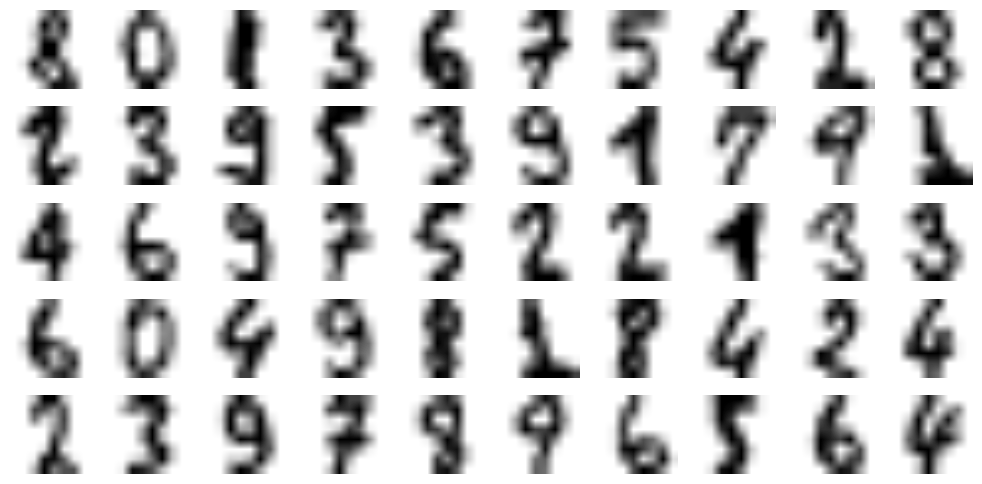

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5)) # Adjusted figure size for better display
for index, X_representative_digit in enumerate(X_representative_digits):
  plt.subplot(k // 10, 10, index + 1) # k=50 means 5 rows, 10 columns
  plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary" ,interpolation="bilinear")
  plt.axis('off')
plt.tight_layout() # Adjust layout to prevent overlapping subplots
plt.show()

In [ ]:
import numpy as np
y_representative_digits = np.array([
8, 0, 1, 3, 6, 7, 5, 4, 2, 8,
2, 3, 9, 5, 3, 9, 1, 7, 9, 1,
4, 6, 9, 7, 5, 2, 2, 1, 3, 3,
6, 0, 4, 9, 8, 1, 8, 4, 2, 4,
2, 3, 9, 7, 8, 9, 6, 5, 6, 4,
])

Estas etiquetas corresponden, en el mismo orden, a las 50 imagenes representativas obtenidas con K-means (asegúrate de que las etiquetas sean correctas).

In [ ]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits,y_representative_digits)
accuracy_representative = log_reg.score(X_test,y_test)
print(accuracy_representative)

0.8337531486146096


### Selección de Meoides en el espacio UMAP

Ahora, aplicaremos K-means en los datos transformados por UMAP (`X_train_umap`) para identificar los 50 *meoides* (observaciones más cercanas a los centroides) que serán utilizados para entrenar el modelo.

In [ ]:
from sklearn.cluster import KMeans

# Aplicar K-means en el espacio UMAP
k_umap = 50 # Ya definido anteriormente, pero para claridad
kmeans_umap = KMeans(
    n_clusters=k_umap,
    random_state=42,
    n_init='auto' # Auto initialization
)
kmeans_umap.fit(X_train_umap)

# Calcular las distancias de cada observación a los centroides en el espacio UMAP
X_train_umap_dist = kmeans_umap.transform(X_train_umap)

# Seleccionar la observación más cercana a cada centroide (el meoide)
representative_digit_idx_umap = X_train_umap_dist.argmin(axis=0)
X_representative_digits_umap = X_train_umap[representative_digit_idx_umap]
y_representative_digits_umap = y_train[representative_digit_idx_umap]

print(f"Se han seleccionado {len(X_representative_digits_umap)} dígitos representativos en el espacio UMAP.")

Se han seleccionado 50 dígitos representativos en el espacio UMAP.


### Entrenamiento de Regresión Logística con Meoides del espacio UMAP

Entrenaremos un nuevo modelo de Regresión Logística utilizando estas 50 observaciones representativas del espacio UMAP y evaluaremos su precisión en el conjunto de prueba, previamente transformado con UMAP.

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg_umap = LogisticRegression(
    max_iter=10_000
)

log_reg_umap.fit(
    X_representative_digits_umap,
    y_representative_digits_umap
)

# Transformar X_test usando el mismo modelo UMAP ajustado a X_train
X_test_umap = umapper.transform(X_test)

accuracy_representative_umap = log_reg_umap.score(
    X_test_umap,
    y_test
)
print(f"Precisión del clasificador con meoides UMAP: {accuracy_representative_umap}")

Precisión del clasificador con meoides UMAP: 0.8312342569269522


Compara:
50 ejemplos iniciales vs. 50 ejemplos representativos.
¿Mejoró la exactitud?

# Preguntas

**¿Cuál fue la exactitud utilizando las primeras 50 observaciones?**

- 0.76

**¿Cuál fue la exactitud utilizando las 50 observaciones representativas?**

- 0.83

**¿Qué estrategia funcionó mejor?**

- La que utiliza 50 muestras representativas para etiquetar.

**¿Por qué seleccionar observaciones cercanas a los centroides puede producir un mejor conjunto de entrenamiento?**

Cada centroide representa el centro promedio de un cluster, y tenemos la idea que se forman clusteres de números parecidos. Al seleccionar la observación real más cercana a cada centroide, obtenemos el ejemplo más representativo de cada de las regiones encontradas por K-means. (ft. hay alguna relación con escoger el más cercano al centroide con MLE?)

En cambio, al utilizar 50 observaciones aleatorias, casi seguramente no representen adecuadamente toda la variedad del conjunto de entrenamiento. Podría ocurrir que no seleccionemos un representativo como el '9'. (con prob.
$\left(\frac{9}{10}\right)^n$
).


La cantidad de etiquetas utilizadas sigue siendo la misma:
50.
Lo único que cambió fue qué observaciones etiquetadas
utilizamos.


# Propagación de etiquetas

Supón ahora que todos los ejemplos pertenecientes a un mismo cluster tienen la etiqueta de su ejemplo representativo.

**Propaga las etiquetas:**

Ahora tienes una etiqueta estimada para las 1,400 observaciones de entrenamiento.

In [ ]:
import numpy as np

y_train_propagated = np.empty(
    len(X_train),
    dtype=np.int64
)

for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

In [ ]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train,y_train_propagated)
accuracy_propagated = log_reg.score(X_test,y_test)
print(f"Precisión con etiquetas propagadas: {accuracy_propagated}")

Precisión con etiquetas propagadas: 0.8690176322418136


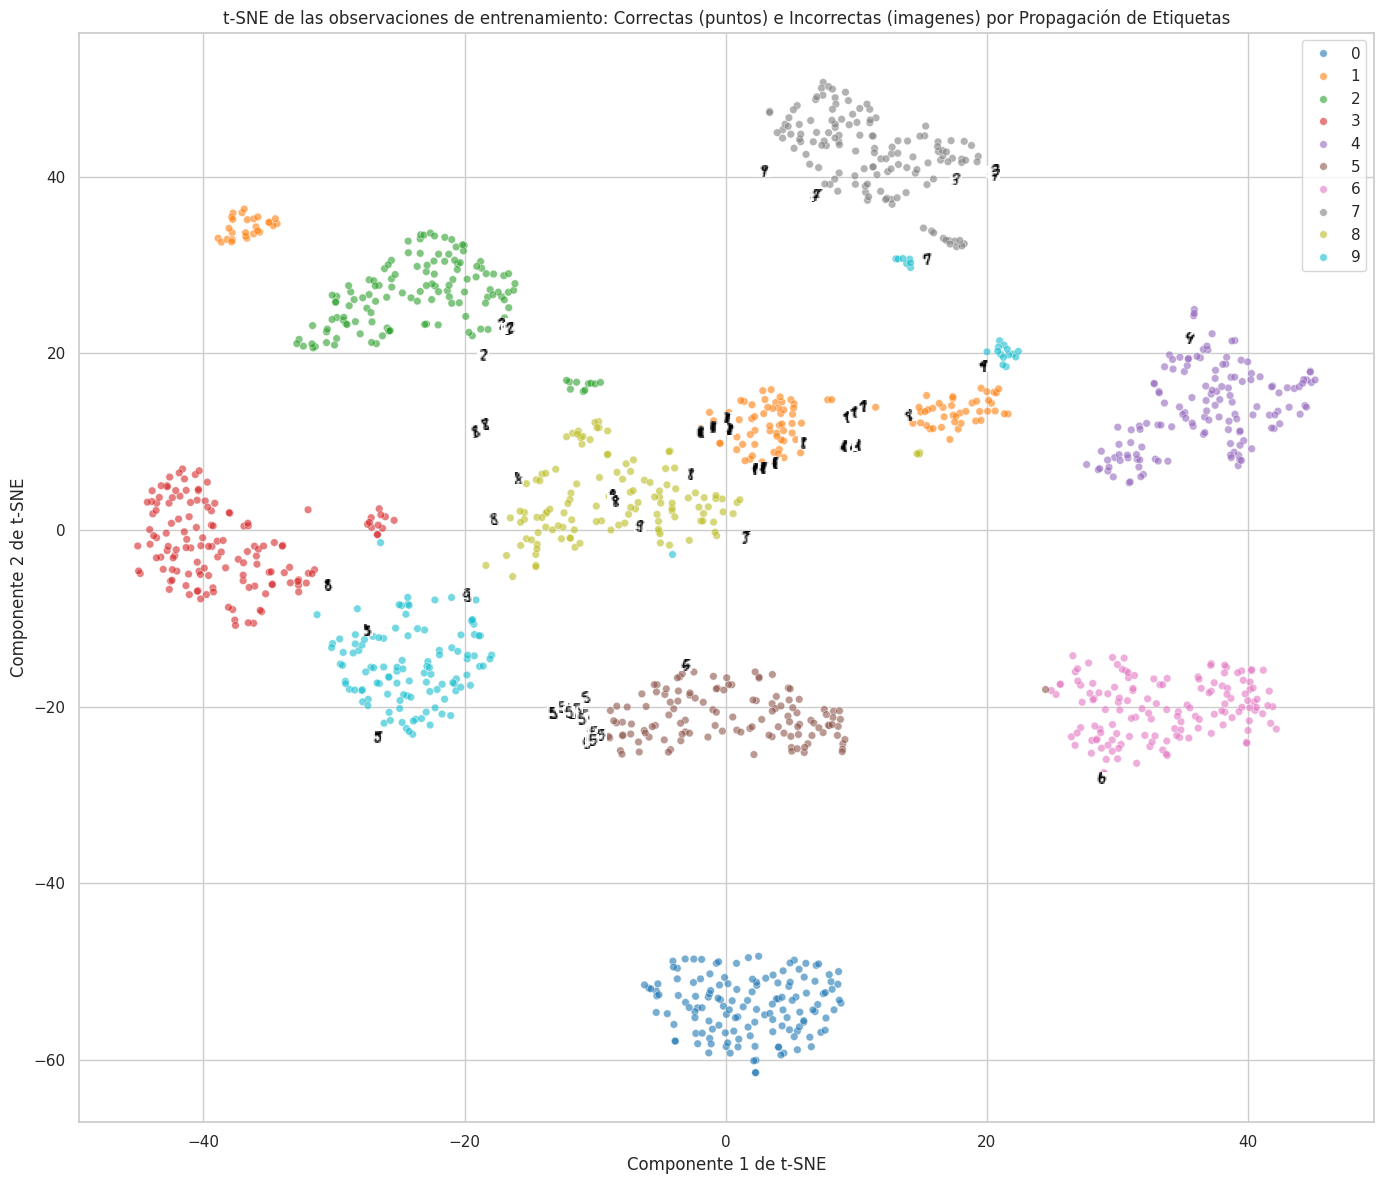

In [ ]:
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Obtener las máscaras para clasificados correctamente y mal clasificados
correctly_classified_train_mask = (y_train_propagated == y_train)
misclassified_train_mask = (y_train_propagated != y_train)

# Preparar datos para los puntos correctamente clasificados
X_train_tsne_correct = X_train_tsne[correctly_classified_train_mask]
y_train_correct = y_train[correctly_classified_train_mask]

# Preparar datos para los puntos mal clasificados (para superponer imagenes)
X_train_tsne_incorrect = X_train_tsne[misclassified_train_mask]
y_train_incorrect = y_train[misclassified_train_mask] # Usar la etiqueta verdadera para la imagen
X_train_incorrect_images = X_train[misclassified_train_mask]

fig, ax = plt.subplots(figsize=(14, 12))

# 1. Graficar los puntos correctamente clasificados con colores
sns.scatterplot(
    x=X_train_tsne_correct[:, 0],
    y=X_train_tsne_correct[:, 1],
    hue=y_train_correct,
    palette='tab10',
    legend='full',
    alpha=0.6, # Transparencia para los puntos
    s=30, # Tamaño de los puntos
    ax=ax
)

# 2. Superponer una muestra de imagenes de los puntos mal clasificados
# Limitar el número de imagenes superpuestas para evitar saturar el gráfico
num_images_to_superimpose_incorrect = min(1000, len(X_train_tsne_incorrect))

if num_images_to_superimpose_incorrect > 0:
    # Seleccionar índices aleatorios de las observaciones mal clasificadas
    random_indices_incorrect = np.random.choice(
        len(X_train_tsne_incorrect),
        num_images_to_superimpose_incorrect,
        replace=False
    )

    for i in random_indices_incorrect:
        x0, y0 = X_train_tsne_incorrect[i] # Coordenadas t-SNE
        img = X_train_incorrect_images[i].reshape(8, 8) # Imagen original 8x8

        imagebox = OffsetImage(img, cmap='binary', zoom=1.0)
        ab = AnnotationBbox(
            imagebox,
            (x0, y0),
            xycoords='data',
            xybox=(0,0),
            boxcoords='offset points',
            frameon=False,
            pad=0.0
        )
        ax.add_artist(ab)

ax.set_title('t-SNE de las observaciones de entrenamiento: Correctas (puntos) e Incorrectas (imagenes) por Propagación de Etiquetas')
ax.set_xlabel('Componente 1 de t-SNE')
ax.set_ylabel('Componente 2 de t-SNE')
plt.tight_layout()
plt.show()

Al propagar las etiquetas estamos suponiendo que:

*   Observaciones del mismo cluster $\implies$ misma clase.

# Preguntas

1.  ¿Es siempre válido este supuesto?
- No. Puede haber como outliers enttre clases, pero no sé como abordaríamos este problema.

2.  ¿Puede un cluster contener imagenes de distintos dígitos?
- Si, y se muestra arriba.

3.  ¿En qué parte del cluster esperarías encontrar observaciones menos confiables?
- En los bordes, especialmente lo esperaría entre el $2, 7, 1$ y $9, 8, 3$. Hubiera hecho una matriz de confusión :(
    Pero ahí se ven que hay 5's en el cluster de 9's, 5's en el cluster de 5's (?) (deberíamos ver también con umap).

Esto nos lleva al siguiente experimento.

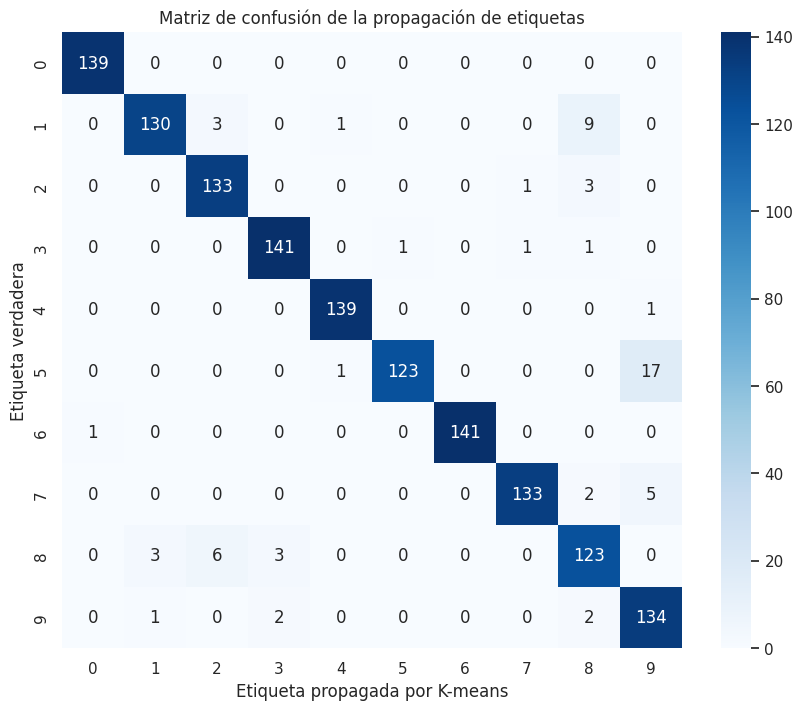

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Matriz de confusión:
# filas    = etiqueta verdadera
# columnas = etiqueta asignada mediante propagación del cluster
cm = confusion_matrix(
    y_train,
    y_train_propagated,
    labels=np.arange(10)
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.arange(10),
    yticklabels=np.arange(10)
)

plt.xlabel("Etiqueta propagada por K-means")
plt.ylabel("Etiqueta verdadera")
plt.title("Matriz de confusión de la propagación de etiquetas")

plt.show()

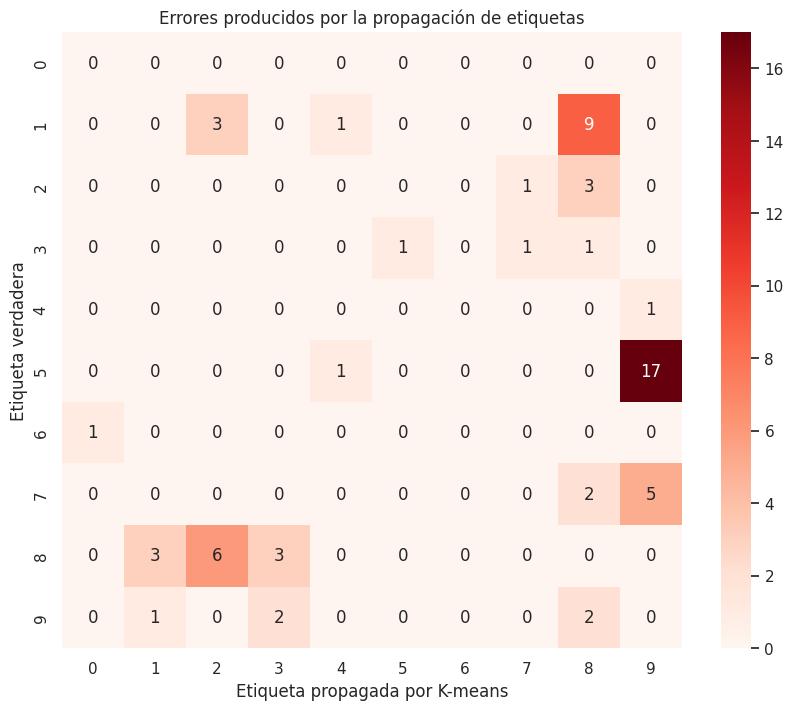

In [ ]:
cm_errors = cm.copy()

# Eliminar los aciertos para visualizar solamente los errores
np.fill_diagonal(cm_errors, 0)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_errors,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=np.arange(10),
    yticklabels=np.arange(10)
)

plt.xlabel("Etiqueta propagada por K-means")
plt.ylabel("Etiqueta verdadera")
plt.title("Errores producidos por la propagación de etiquetas")

plt.show()

Justo esto no me lo esperaba!

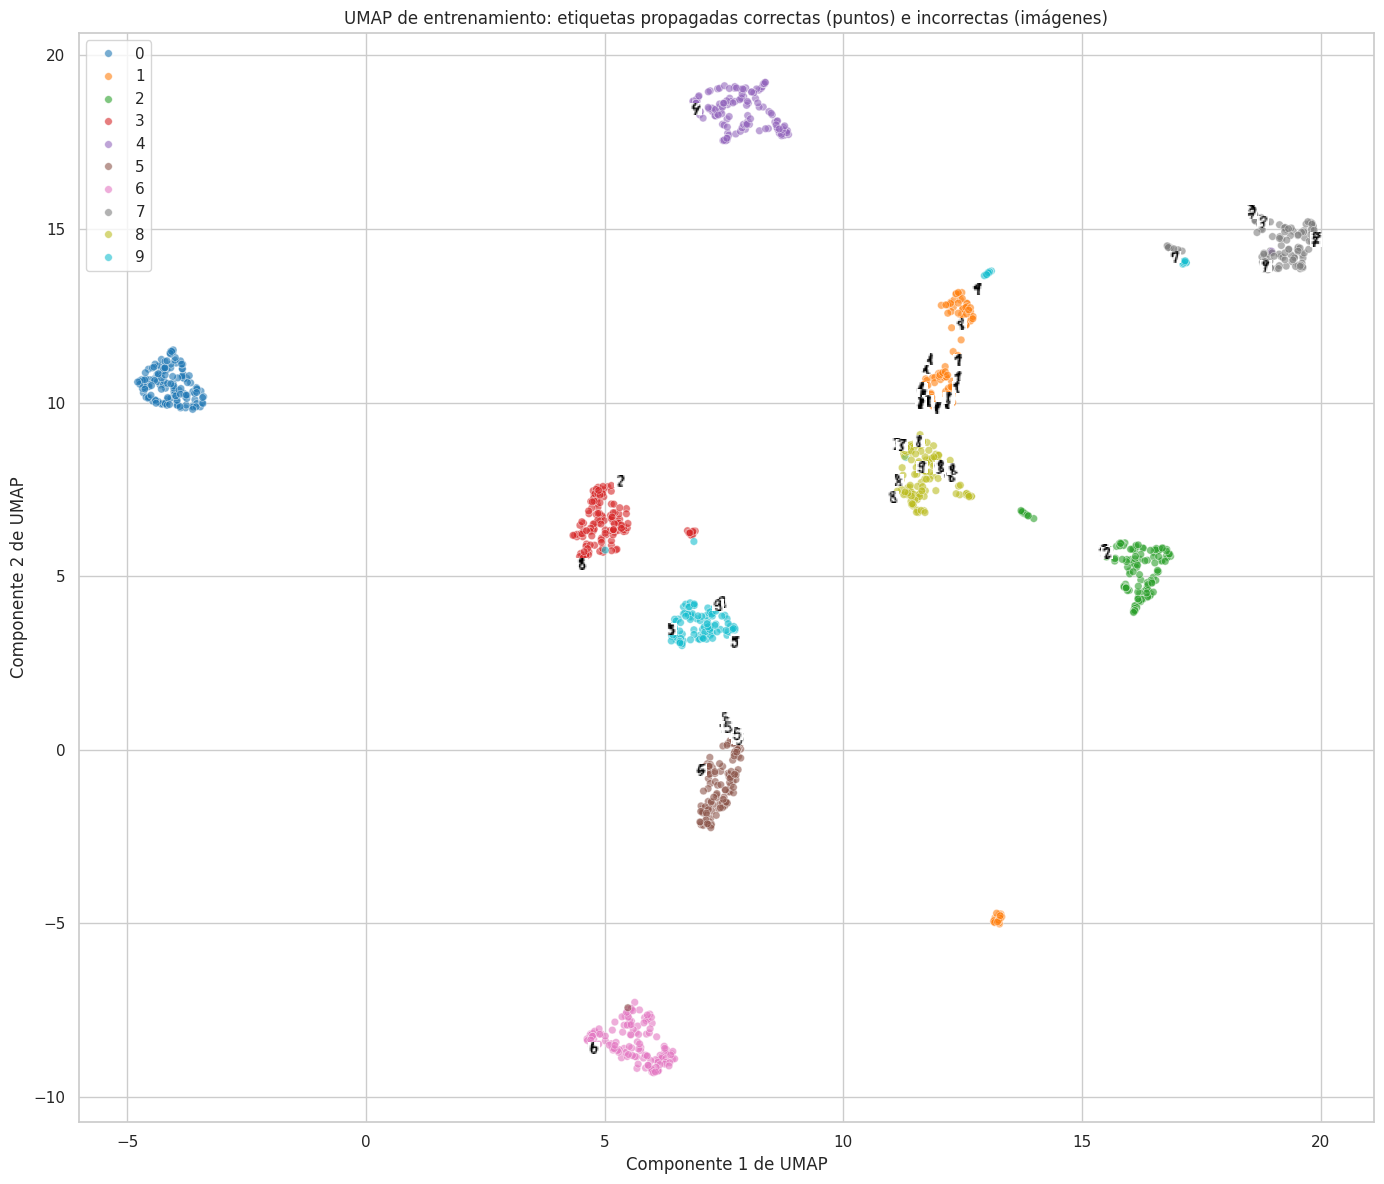

In [ ]:
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Máscaras: comparar la etiqueta propagada por K-means
# contra la etiqueta verdadera
correctly_classified_train_mask = (y_train_propagated == y_train)
misclassified_train_mask = (y_train_propagated != y_train)

# Puntos correctamente etiquetados
X_train_umap_correct = X_train_umap[correctly_classified_train_mask]
y_train_correct = y_train[correctly_classified_train_mask]

# Puntos incorrectamente etiquetados
X_train_umap_incorrect = X_train_umap[misclassified_train_mask]
y_train_incorrect = y_train[misclassified_train_mask]
X_train_incorrect_images = X_train[misclassified_train_mask]

fig, ax = plt.subplots(figsize=(14, 12))

# 1. Graficar las observaciones correctamente etiquetadas
sns.scatterplot(
    x=X_train_umap_correct[:, 0],
    y=X_train_umap_correct[:, 1],
    hue=y_train_correct,
    palette="tab10",
    legend="full",
    alpha=0.6,
    s=30,
    ax=ax
)

# 2. Superponer las imágenes de las observaciones
# cuya etiqueta fue propagada incorrectamente
num_images_to_superimpose_incorrect = min(
    1000,
    len(X_train_umap_incorrect)
)

if num_images_to_superimpose_incorrect > 0:

    random_indices_incorrect = np.random.choice(
        len(X_train_umap_incorrect),
        num_images_to_superimpose_incorrect,
        replace=False
    )

    for i in random_indices_incorrect:

        # Coordenadas UMAP
        x0, y0 = X_train_umap_incorrect[i]

        # Imagen original 8x8
        img = X_train_incorrect_images[i].reshape(8, 8)

        imagebox = OffsetImage(
            img,
            cmap="binary",
            zoom=1.0
        )

        ab = AnnotationBbox(
            imagebox,
            (x0, y0),
            xycoords="data",
            xybox=(0, 0),
            boxcoords="offset points",
            frameon=False,
            pad=0.0
        )

        ax.add_artist(ab)

ax.set_title(
    "UMAP de entrenamiento: etiquetas propagadas correctas "
    "(puntos) e incorrectas (imágenes)"
)
ax.set_xlabel("Componente 1 de UMAP")
ax.set_ylabel("Componente 2 de UMAP")

plt.tight_layout()
plt.show()

# Propagación parcial

En lugar de propagar la etiqueta a todo el cluster, propágala solamente a las observaciones más cercanas al centroide.

Conserva únicamente el **50%** de las observaciones más cercanas al centroide de cada cluster.

La idea es eliminar observaciones alejadas del centroide, que pueden ser menos representativas del cluster.

Obtén la distancia de cada observación al centroide de su propio cluster:

Después, para cada cluster, calcula el percentil 50 de las distancias y elimina las observaciones que se encuentren más lejos.

In [ ]:
percentile_closest = 50

X_cluster_dist = X_digits_dist[
    np.arange(len(X_train)),
    kmeans.labels_
]

In [ ]:
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist,percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

In [ ]:
partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

Número de observaciones con etiquetas parcialmente propagadas: 713
Número de observaciones descartadas por la propagación parcial: 687


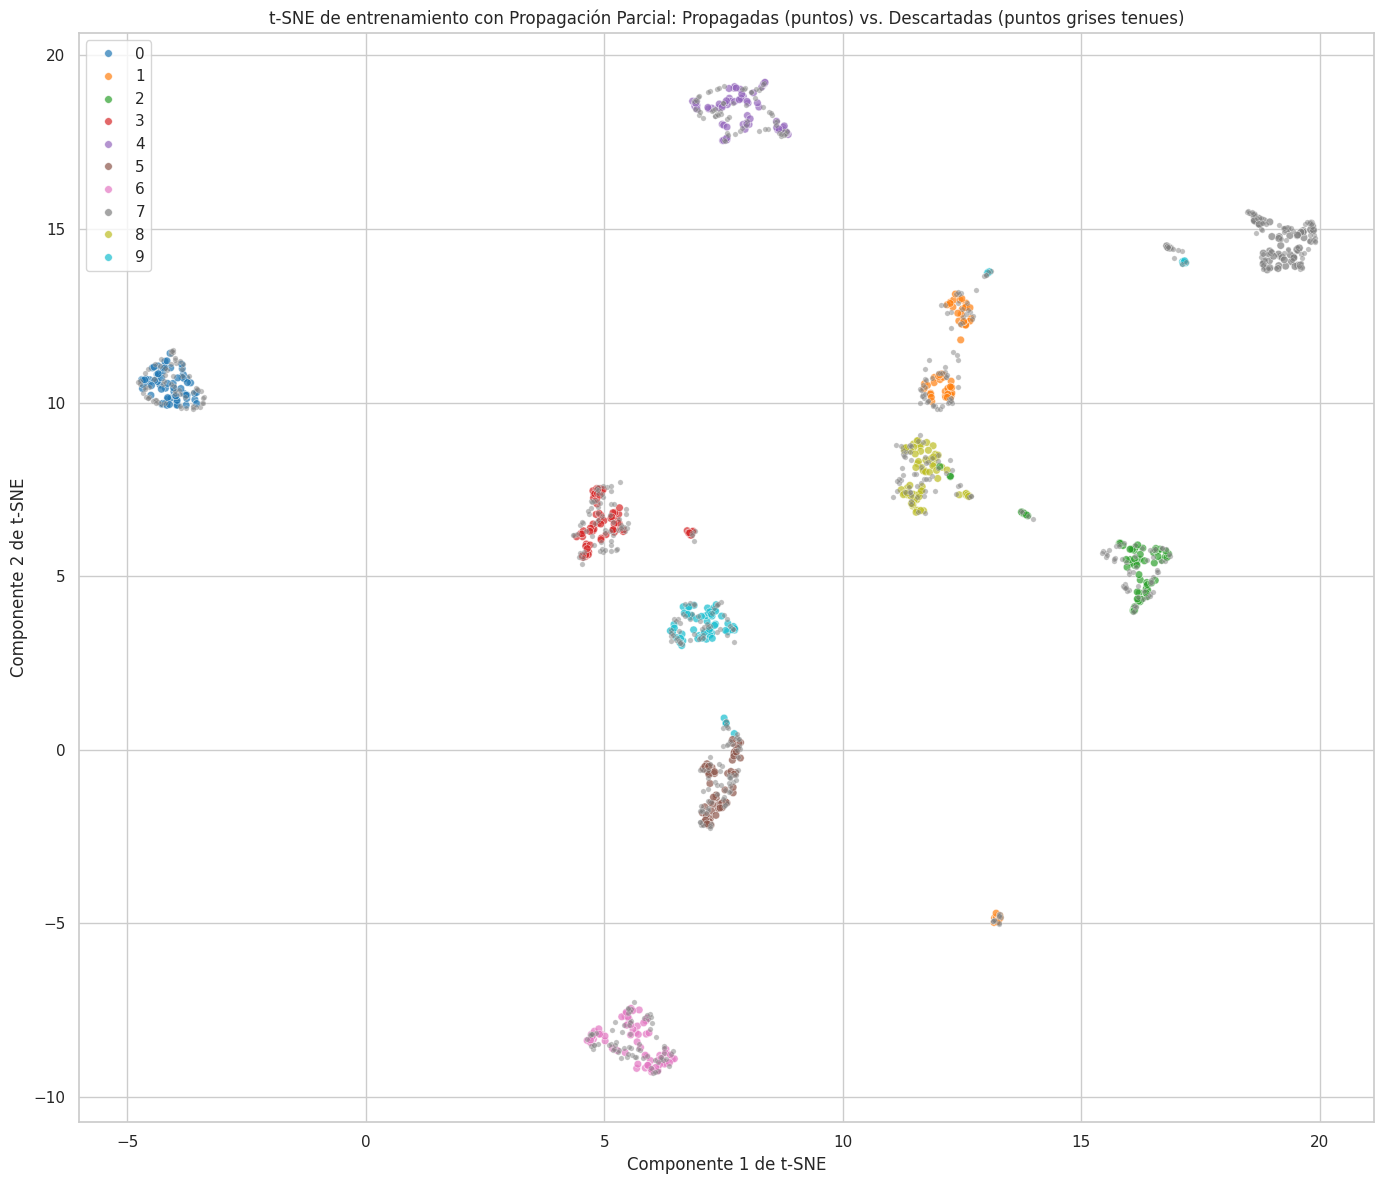

In [ ]:
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Identificar las observaciones que fueron parcialmente propagadas
propagated_mask = partially_propagated

# Identificar las observaciones que NO fueron propagadas (las que fueron descartadas)
not_propagated_mask = ~partially_propagated

# --- Datos para los puntos coloreados (las que SÍ fueron propagadas) ---
X_train_tsne_propagated = X_train_umap[propagated_mask]
y_train_propagated_labels_only = y_train_propagated[propagated_mask]

# --- Datos para los puntos tenues (las que NO fueron propagadas) ---
X_train_tsne_not_propagated = X_train_umap[not_propagated_mask]
X_train_not_propagated_images = X_train[not_propagated_mask]
y_train_not_propagated = y_train[not_propagated_mask] # Usamos la etiqueta verdadera para estas imagenes

print(f"Número de observaciones con etiquetas parcialmente propagadas: {len(X_train_tsne_propagated)}")
print(f"Número de observaciones descartadas por la propagación parcial: {len(X_train_tsne_not_propagated)}")

fig, ax = plt.subplots(figsize=(14, 12))

# 1. Graficar los puntos con etiquetas propagadas (los que SÍ se usaron)
sns.scatterplot(
    x=X_train_tsne_propagated[:, 0],
    y=X_train_tsne_propagated[:, 1],
    hue=y_train_propagated_labels_only,
    palette='tab10',
    legend='full',
    alpha=0.7, # Transparencia para los puntos
    s=30, # Tamaño de los puntos
    ax=ax
)

# 2. Graficar TODOS los puntos NO propagados como puntos tenues de color gris
sns.scatterplot(
    x=X_train_tsne_not_propagated[:, 0],
    y=X_train_tsne_not_propagated[:, 1],
    color='gray', # Color gris para los puntos descartados
    alpha=0.5,    # Baja transparencia
    s=15,         # Tamaño más pequeño
    ax=ax
)

# 3. Superponer una muestra de imagenes de los puntos NO propagados (los que se descartaron)
# Limitar el número de imagenes superpuestas para evitar saturar el gráfico
num_images_to_superimpose_discarded = min(0, len(X_train_tsne_not_propagated))

if num_images_to_superimpose_discarded > 0:
    # Seleccionar índices aleatorios de las observaciones NO propagadas
    random_indices_discarded = np.random.choice(
        len(X_train_tsne_not_propagated),
        num_images_to_superimpose_discarded,
        replace=False
    )

    for i in random_indices_discarded:
        x0, y0 = X_train_tsne_not_propagated[i] # Coordenadas t-SNE
        img = X_train_not_propagated_images[i].reshape(8, 8) # Imagen original 8x8

        imagebox = OffsetImage(
            img,
            cmap='binary',
            zoom=1.0
        )
        ab = AnnotationBbox(
            imagebox,
            (x0, y0),
            xycoords='data',
            xybox=(0,0),
            boxcoords='offset points',
            frameon=False,
            pad=0.0
        )
        ax.add_artist(ab)

ax.set_title('t-SNE de entrenamiento con Propagación Parcial: Propagadas (puntos) vs. Descartadas (puntos grises tenues)')
ax.set_xlabel('Componente 1 de t-SNE')
ax.set_ylabel('Componente 2 de t-SNE')
plt.tight_layout()
plt.show()

wow! como que umap >> t-sne

Número de observaciones con etiquetas parcialmente propagadas: 713
Número de observaciones descartadas por la propagación parcial: 687


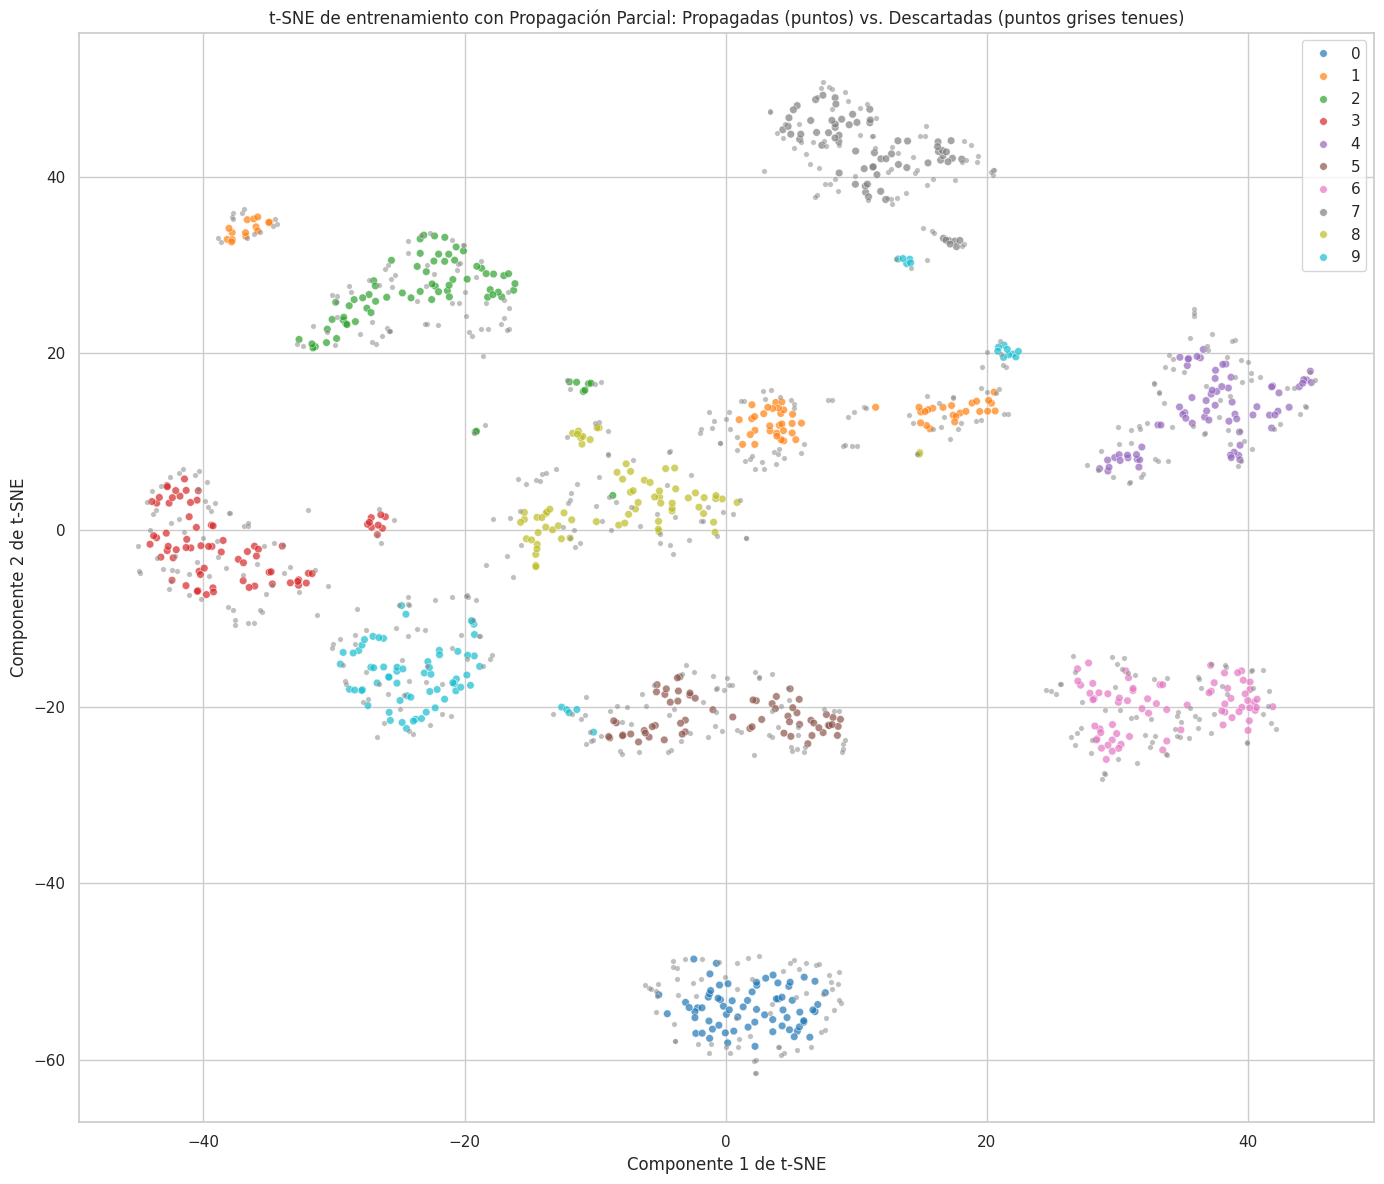

In [ ]:
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Identificar las observaciones que fueron parcialmente propagadas
propagated_mask = partially_propagated

# Identificar las observaciones que NO fueron propagadas (las que fueron descartadas)
not_propagated_mask = ~partially_propagated

# --- Datos para los puntos coloreados (las que SÍ fueron propagadas) ---
X_train_tsne_propagated = X_train_tsne[propagated_mask]
y_train_propagated_labels_only = y_train_propagated[propagated_mask]

# --- Datos para los puntos tenues (las que NO fueron propagadas) ---
X_train_tsne_not_propagated = X_train_tsne[not_propagated_mask]
X_train_not_propagated_images = X_train[not_propagated_mask]
y_train_not_propagated = y_train[not_propagated_mask] # Usamos la etiqueta verdadera para estas imagenes

print(f"Número de observaciones con etiquetas parcialmente propagadas: {len(X_train_tsne_propagated)}")
print(f"Número de observaciones descartadas por la propagación parcial: {len(X_train_tsne_not_propagated)}")

fig, ax = plt.subplots(figsize=(14, 12))

# 1. Graficar los puntos con etiquetas propagadas (los que SÍ se usaron)
sns.scatterplot(
    x=X_train_tsne_propagated[:, 0],
    y=X_train_tsne_propagated[:, 1],
    hue=y_train_propagated_labels_only,
    palette='tab10',
    legend='full',
    alpha=0.7, # Transparencia para los puntos
    s=30, # Tamaño de los puntos
    ax=ax
)

# 2. Graficar TODOS los puntos NO propagados como puntos tenues de color gris
sns.scatterplot(
    x=X_train_tsne_not_propagated[:, 0],
    y=X_train_tsne_not_propagated[:, 1],
    color='gray', # Color gris para los puntos descartados
    alpha=0.5,    # Baja transparencia
    s=15,         # Tamaño más pequeño
    ax=ax
)

# 3. Superponer una muestra de imagenes de los puntos NO propagados (los que se descartaron)
# Limitar el número de imagenes superpuestas para evitar saturar el gráfico
num_images_to_superimpose_discarded = min(0, len(X_train_tsne_not_propagated))

if num_images_to_superimpose_discarded > 0:
    # Seleccionar índices aleatorios de las observaciones NO propagadas
    random_indices_discarded = np.random.choice(
        len(X_train_tsne_not_propagated),
        num_images_to_superimpose_discarded,
        replace=False
    )

    for i in random_indices_discarded:
        x0, y0 = X_train_tsne_not_propagated[i] # Coordenadas t-SNE
        img = X_train_not_propagated_images[i].reshape(8, 8) # Imagen original 8x8

        imagebox = OffsetImage(
            img,
            cmap='binary',
            zoom=1.0
        )
        ab = AnnotationBbox(
            imagebox,
            (x0, y0),
            xycoords='data',
            xybox=(0,0),
            boxcoords='offset points',
            frameon=False,
            pad=0.0
        )
        ax.add_artist(ab)

ax.set_title('t-SNE de entrenamiento con Propagación Parcial: Propagadas (puntos) vs. Descartadas (puntos grises tenues)')
ax.set_xlabel('Componente 1 de t-SNE')
ax.set_ylabel('Componente 2 de t-SNE')
plt.tight_layout()
plt.show()

Número de observaciones con etiquetas parcialmente propagadas: 713
Número de observaciones descartadas por la propagación parcial: 687


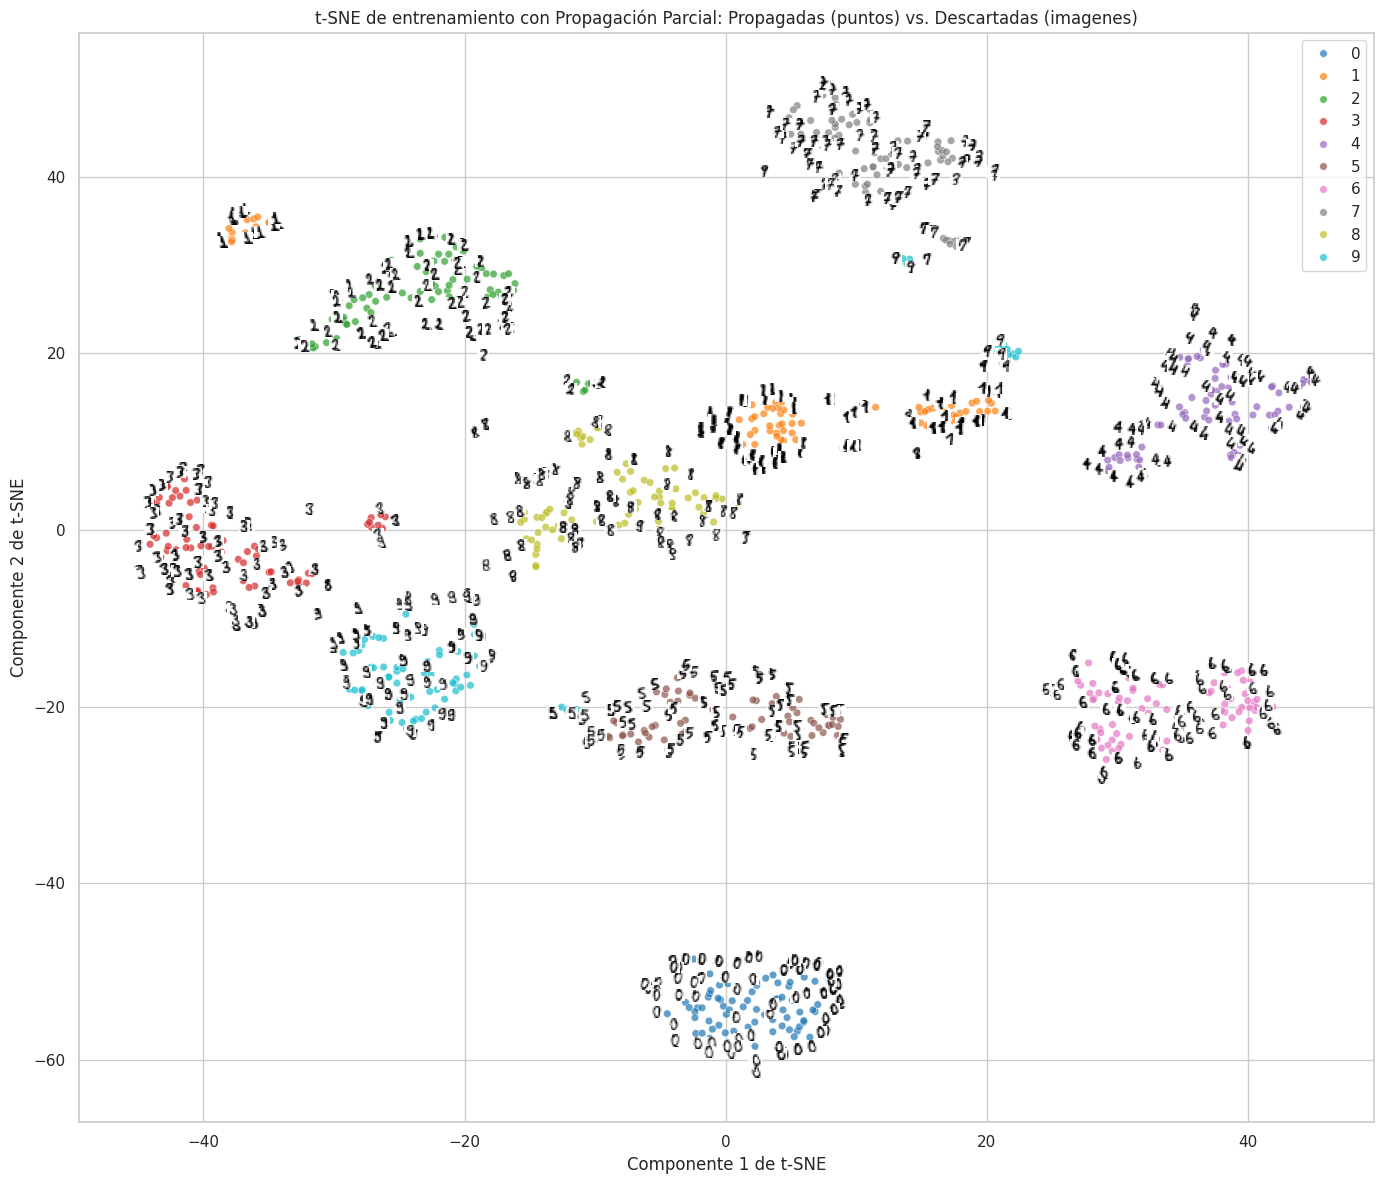

In [ ]:
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Identificar las observaciones que fueron parcialmente propagadas
propagated_mask = partially_propagated

# Identificar las observaciones que NO fueron propagadas (las que fueron descartadas)
not_propagated_mask = ~partially_propagated

# --- Datos para los puntos coloreados (las que SÍ fueron propagadas) ---
X_train_tsne_propagated = X_train_tsne[propagated_mask]
y_train_propagated_labels_only = y_train_propagated[propagated_mask]

# --- Datos para los puntos tenues (las que NO fueron propagadas) ---
X_train_tsne_not_propagated = X_train_tsne[not_propagated_mask]
X_train_not_propagated_images = X_train[not_propagated_mask]
y_train_not_propagated = y_train[not_propagated_mask] # Usamos la etiqueta verdadera para estas imagenes

print(f"Número de observaciones con etiquetas parcialmente propagadas: {len(X_train_tsne_propagated)}")
print(f"Número de observaciones descartadas por la propagación parcial: {len(X_train_tsne_not_propagated)}")

fig, ax = plt.subplots(figsize=(14, 12))

# 1. Graficar los puntos con etiquetas propagadas (los que SÍ se usaron)
sns.scatterplot(
    x=X_train_tsne_propagated[:, 0],
    y=X_train_tsne_propagated[:, 1],
    hue=y_train_propagated_labels_only,
    palette='tab10',
    legend='full',
    alpha=0.7, # Transparencia para los puntos
    s=30, # Tamaño de los puntos
    ax=ax
)

# 2. Graficar TODOS los puntos NO propagados como puntos tenues de color gris
sns.scatterplot(
    x=X_train_tsne_not_propagated[:, 0],
    y=X_train_tsne_not_propagated[:, 1],
    color='gray', # Color gris para los puntos descartados
    alpha=0.5,    # Baja transparencia
    s=15,         # Tamaño más pequeño
    ax=ax
)

# 3. Superponer una muestra de imagenes de los puntos NO propagados (los que se descartaron)
# Limitar el número de imagenes superpuestas para evitar saturar el gráfico
num_images_to_superimpose_discarded = min(1000, len(X_train_tsne_not_propagated))

if num_images_to_superimpose_discarded > 0:
    # Seleccionar índices aleatorios de las observaciones NO propagadas
    random_indices_discarded = np.random.choice(
        len(X_train_tsne_not_propagated),
        num_images_to_superimpose_discarded,
        replace=False
    )

    for i in random_indices_discarded:
        x0, y0 = X_train_tsne_not_propagated[i] # Coordenadas t-SNE
        img = X_train_not_propagated_images[i].reshape(8, 8) # Imagen original 8x8

        imagebox = OffsetImage(
            img,
            cmap='binary',
            zoom=1.0
        )
        ab = AnnotationBbox(
            imagebox,
            (x0, y0),
            xycoords='data',
            xybox=(0,0),
            boxcoords='offset points',
            frameon=False,
            pad=0.0
        )
        ax.add_artist(ab)

ax.set_title('t-SNE de entrenamiento con Propagación Parcial: Propagadas (puntos) vs. Descartadas (imagenes)')
ax.set_xlabel('Componente 1 de t-SNE')
ax.set_ylabel('Componente 2 de t-SNE')
plt.tight_layout()
plt.show()

Selecciona únicamente las observaciones que no fueron eliminadas:

Ahora tienes un conjunto de entrenamiento más pequeño, pero con etiquetas propagadas únicamente a observaciones relativamente cercanas al centroide.

In [ ]:
log_reg = LogisticRegression(
    max_iter=10_000
)

log_reg.fit(
    X_train_partially_propagated,
    y_train_partially_propagated
)

accuracy_partial = log_reg.score(
    X_test,
    y_test
)

print(f"Precisión con propagación parcial: {accuracy_partial}")

Precisión con propagación parcial: 0.8841309823677582


# Tabla de resultados

Identifica cuál de los cuatro métodos produjo la mayor exactitud.

In [ ]:
import pandas as pd

accuracies = {
    "50 observaciones iniciales": accuracy,
    "50 observaciones representativas": accuracy_representative,
    "50 observaciones representativas UMAP": accuracy_representative_umap,
    "Propagación de etiquetas": accuracy_propagated,
    "Propagación parcial": accuracy_partial
}

# Convertir a pandas DataFrame para una mejor visualización
accuracies_df = pd.DataFrame(accuracies.items(), columns=['Estrategia', 'Precisión'])
display(accuracies_df.sort_values(by='Precisión', ascending=False))

,Estrategia,Precisión
4,Propagación parcial,0.884131
3,Propagación de etiquetas,0.869018
1,50 observaciones representativas,0.833753
2,50 observaciones representativas UMAP,0.831234
0,50 observaciones iniciales,0.758186


El que tuvo mayor exactitud fue el de Propagación parcial con 0.884131

Ejecutando experimentos para diferentes cantidades de observaciones etiquetadas...
  - n_labeled = 10
  - n_labeled = 20
  - n_labeled = 30
  - n_labeled = 40
  - n_labeled = 50
  - n_labeled = 60
  - n_labeled = 70
  - n_labeled = 80
  - n_labeled = 90
  - n_labeled = 100
  - n_labeled = 200
  - n_labeled = 300
  - n_labeled = 400
  - n_labeled = 500
  - n_labeled = 750
  - n_labeled = 1000


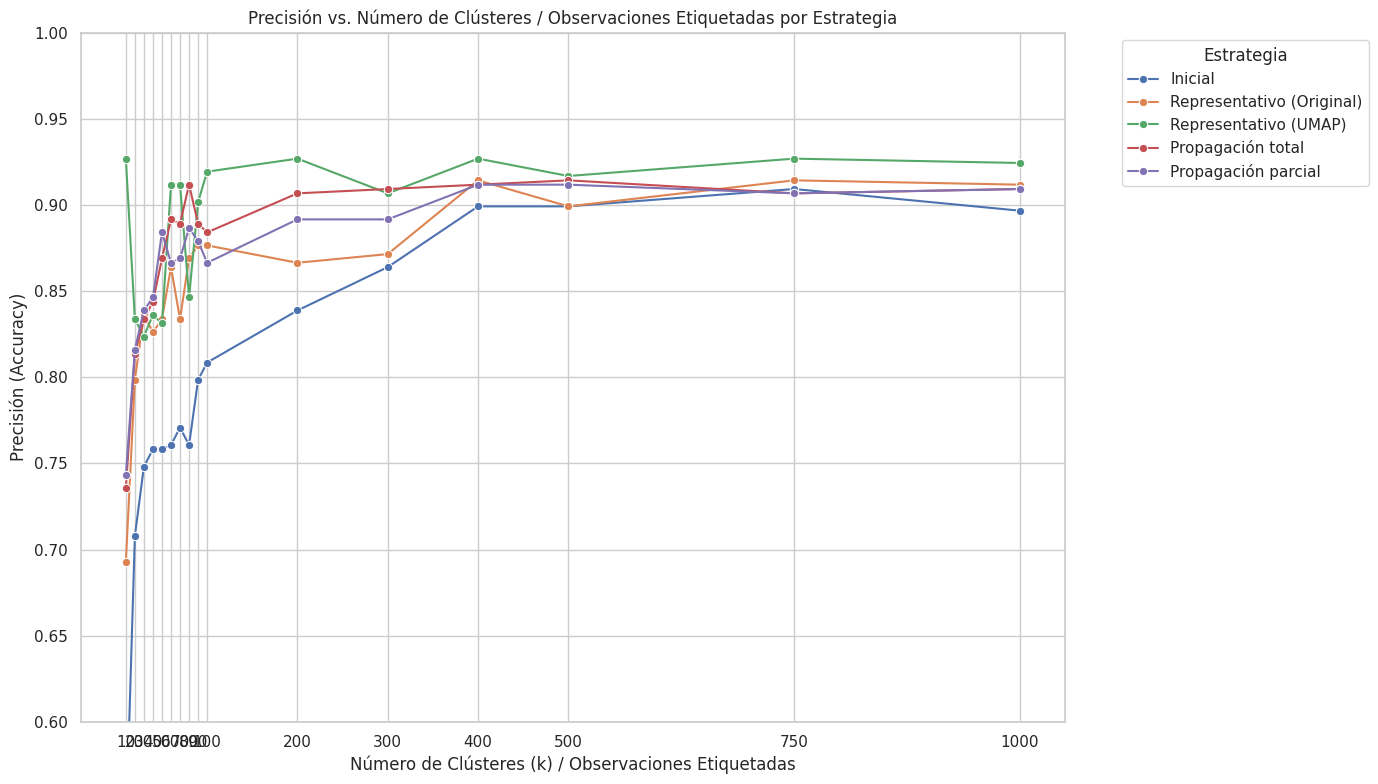


Tabla de resultados:



,Inicial,Representativo (Original),Representativo (UMAP),Propagación total,Propagación parcial
num_labeled,,,,,
10,0.534005,0.692695,0.926952,0.735516,0.743073
20,0.707809,0.798489,0.833753,0.813602,0.816121
30,0.748111,0.836272,0.823678,0.833753,0.838791
40,0.758186,0.826196,0.836272,0.843829,0.846348
50,0.758186,0.833753,0.831234,0.869018,0.884131
60,0.760705,0.863980,0.911839,0.891688,0.866499
70,0.770781,0.833753,0.911839,0.889169,0.869018
80,0.760705,0.869018,0.846348,0.911839,0.886650
90,0.798489,0.876574,0.901763,0.889169,0.879093


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")

def run_experiment_for_n_labeled(n_labeled_val, X_train, y_train, X_test, y_test, umapper_model, X_train_umap_data):
    """
    Runs the classification experiments for a given number of labeled examples (n_labeled_val,
    which also corresponds to n_clusters for KMeans strategies).
    """
    results = {}

    # Strategy 1: Initial n_labeled observations
    # Ensure n_labeled_val does not exceed available training data
    actual_n_labeled_samples = min(n_labeled_val, len(X_train))

    if actual_n_labeled_samples > 0:
        log_reg_initial = LogisticRegression(max_iter=10_000, random_state=42)
        log_reg_initial.fit(X_train[:actual_n_labeled_samples], y_train[:actual_n_labeled_samples])
        results["Inicial"] = log_reg_initial.score(X_test, y_test)
    else:
        results["Inicial"] = np.nan # Cannot train with 0 samples

    # Strategies involving KMeans
    k_val = n_labeled_val # K-means will use this as n_clusters
    if k_val < 2: # KMeans requires n_clusters >= 2
        k_val = 2
    if k_val > len(X_train): # KMeans n_clusters cannot exceed the number of samples
        k_val = len(X_train)

    # Re-instantiate KMeans for each run to ensure a fresh state
    kmeans_model = KMeans(n_clusters=k_val, random_state=42, n_init='auto')

    # Fit KMeans on original training data
    kmeans_model.fit(X_train)
    X_digits_dist_k = kmeans_model.transform(X_train) # Distance of each point to all centroids

    # Get representative digits (meoides) from the original space
    representative_digit_idx_k = X_digits_dist_k.argmin(axis=0)
    X_representative_digits_k = X_train[representative_digit_idx_k]
    y_representative_digits_k = y_train[representative_digit_idx_k]

    # Strategy 2: Representative observations (original space)
    log_reg_representative = LogisticRegression(max_iter=10_000, random_state=42)
    if len(X_representative_digits_k) > 0:
        log_reg_representative.fit(X_representative_digits_k, y_representative_digits_k)
        results["Representativo (Original)"] = log_reg_representative.score(X_test, y_test)
    else:
        results["Representativo (Original)"] = np.nan

    # Strategy 3: Representative observations (UMAP space)
    kmeans_umap_model = KMeans(n_clusters=k_val, random_state=42, n_init='auto')
    kmeans_umap_model.fit(X_train_umap_data) # Fit on the pre-computed UMAP projection of X_train
    X_train_umap_dist_k = kmeans_umap_model.transform(X_train_umap_data)
    representative_digit_idx_umap_k = X_train_umap_dist_k.argmin(axis=0)

    X_representative_digits_umap_k = X_train_umap_data[representative_digit_idx_umap_k]
    y_representative_digits_umap_k = y_train[representative_digit_idx_umap_k]

    log_reg_umap = LogisticRegression(max_iter=10_000, random_state=42)
    if len(X_representative_digits_umap_k) > 0:
        log_reg_umap.fit(X_representative_digits_umap_k, y_representative_digits_umap_k)
        X_test_umap_transformed = umapper_model.transform(X_test) # Transform X_test using the already fitted umapper
        results["Representativo (UMAP)"] = log_reg_umap.score(X_test_umap_transformed, y_test)
    else:
        results["Representativo (UMAP)"] = np.nan

    # Strategy 4: Label propagation (full cluster) - assumes all points in a cluster have the same label as its representative
    y_train_propagated_k = np.full(len(X_train), -1, dtype=np.int64) # Initialize with a placeholder

    for i in np.unique(kmeans_model.labels_): # Iterate over actual unique cluster labels found by KMeans
        points_in_cluster_mask = (kmeans_model.labels_ == i)
        # Propagate the label of the representative digit for this cluster `i`
        y_train_propagated_k[points_in_cluster_mask] = y_train[representative_digit_idx_k[i]]

    log_reg_propagated = LogisticRegression(max_iter=10_000, random_state=42)
    valid_propagated_mask = (y_train_propagated_k != -1) # Filter out points that were not assigned a label (e.g., if a cluster was empty)
    if np.any(valid_propagated_mask):
        log_reg_propagated.fit(X_train[valid_propagated_mask], y_train_propagated_k[valid_propagated_mask])
        results["Propagación total"] = log_reg_propagated.score(X_test, y_test)
    else:
        results["Propagación total"] = np.nan

    # Strategy 5: Partial propagation (only to the 50% closest to the centroid)
    percentile_closest = 50 # As defined in the notebook context
    X_cluster_dist_k = X_digits_dist_k[np.arange(len(X_train)), kmeans_model.labels_] # Distance of each point to its assigned centroid

    partially_propagated_mask = np.zeros(len(X_train), dtype=bool)
    y_partial_propagation_labels = np.full(len(X_train), -1, dtype=np.int64)

    for i in np.unique(kmeans_model.labels_):
        in_cluster = (kmeans_model.labels_ == i)
        cluster_dist_for_i = X_cluster_dist_k[in_cluster]

        if len(cluster_dist_for_i) > 0:
            cutoff_distance = np.percentile(cluster_dist_for_i, percentile_closest)
            closer_than_cutoff = (X_cluster_dist_k <= cutoff_distance)
            points_to_propagate = in_cluster & closer_than_cutoff

            partially_propagated_mask[points_to_propagate] = True
            y_partial_propagation_labels[points_to_propagate] = y_train[representative_digit_idx_k[i]]

    X_train_partially_propagated_k = X_train[partially_propagated_mask]
    y_train_partially_propagated_k = y_partial_propagation_labels[partially_propagated_mask]

    log_reg_partial = LogisticRegression(max_iter=10_000, random_state=42)
    if len(X_train_partially_propagated_k) > 0:
        log_reg_partial.fit(X_train_partially_propagated_k, y_train_partially_propagated_k)
        results["Propagación parcial"] = log_reg_partial.score(X_test, y_test)
    else:
        results["Propagación parcial"] = np.nan

    return results

# Define the list of n_labeled values to test
n_labeled_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 750, 1000]

all_results = []
print("Ejecutando experimentos para diferentes cantidades de observaciones etiquetadas...")
for n in n_labeled_values:
    print(f"  - n_labeled = {n}")
    # Pass existing variables from the kernel state
    res = run_experiment_for_n_labeled(n, X_train, y_train, X_test, y_test, umapper, X_train_umap)
    res['num_labeled'] = n
    all_results.append(res)

results_df = pd.DataFrame(all_results)

# Melt the DataFrame for easier plotting with seaborn
results_melted = results_df.melt('num_labeled', var_name='Estrategia', value_name='Precisión')

plt.figure(figsize=(14, 8))
sns.lineplot(data=results_melted, x='num_labeled', y='Precisión', hue='Estrategia', marker='o')
plt.title('Precisión vs. Número de Clústeres / Observaciones Etiquetadas por Estrategia')
plt.xlabel('Número de Clústeres (k) / Observaciones Etiquetadas')
plt.ylabel('Precisión (Accuracy)')
plt.grid(True)
plt.legend(title='Estrategia', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(n_labeled_values)
plt.ylim(0.6, 1.0) # Set a reasonable y-axis limit for accuracy
plt.tight_layout()
plt.show()

print("\nTabla de resultados:\n")
display(results_df.set_index('num_labeled'))

#  Preguntas

1. **¿Por qué las 50 observaciones representativas pueden ser mejores que las primeras 50 observaciones?**

- Cada centroide representa el centro promedio de un cluster, y tenemos la idea que se forman clusteres de números parecidos. Al seleccionar la observación real más cercana a cada centroide, obtenemos el ejemplo más representativo de cada de las regiones encontradas por K-means. (ft. hay alguna relación con escoger el más cercano al centroide con MLE?)

- En cambio, al utilizar 50 observaciones aleatorias, casi seguramente no representen adecuadamente toda la variedad del conjunto de entrenamiento. Podría ocurrir que no seleccionemos un representativo como el '9'. (con prob.
    $\left(\frac{9}{10}\right)^n$
    ).

2. **¿Qué representa una imagen representativa de un cluster?**

- Si una imagen esta en un cluster, es porque el centroide de ese cluster era su mas cercano. Creamos como esteriotipos (centroides) y a los puntos cercanon, los que más se parecen, los metemos dentro del esteriotipo.

3. **¿Qué supuesto hacemos al propagar la etiqueta de la imagen representativa a todo el cluster?**

- Que las observaciones que pertenecen al mismo cluster también pertenecen a la misma clase que su centroide.

4. **¿Por qué este supuesto puede fallar?**

- Porque un mismo cluster puede contener imagenes de diferentes clases.

5. **¿Por qué conservar únicamente las observaciones cercanas al centroide puede mejorar los resultados?**

- Porque las observaciones cercanas al centroide suelen ser más representativas del cluster. Al eliminar las más alejadas, reducimos la posibilidad de entrenar con etiquetas propagadas incorrectamente, las etiquetas no aprendidas pasan por regresion logística, que tiene un método diferente de asignar clasificaciones.

6. **¿Qué método obtuvo la mayor exactitud?**

Propagación parcial	con 0.88